# 03 — Bias Mitigation: Race-Blind Model + Fairlearn Post-Processing

Two things are tested here:

1. **Does removing race as a model feature fix the disparity?** (Spoiler, and a
   well-documented result in the fairness literature: no — proxy variables like
   `priors_count` carry race-correlated signal even when race itself is dropped.)
2. **Fairlearn's `ThresholdOptimizer`**, a post-processing method that picks a
   (possibly different) decision threshold per group to equalize false-positive and
   false-negative rates, subject to minimizing accuracy loss.

In [1]:
import sys
sys.path.insert(0, "../src")
import pandas as pd
from audit import group_metrics, equalized_odds_gap, disparate_impact_ratio
from mitigation import train_and_predict, apply_equalized_odds_mitigation, compare_before_after

df = pd.read_csv("../data/raw/compas_scores.csv")
df = df[df["race"].isin(["African-American", "Caucasian"])].reset_index(drop=True)
len(df)

5278

## Step 1: train a race-blind logistic regression

Features: `age_cat`, `c_charge_degree`, `sex`, `priors_count` — race is never passed
to the model.

In [2]:
model, train, test = train_and_predict(df)
before_metrics = group_metrics(test, "race", "two_year_recid", "pred_unmitigated")
before_metrics

,group,n,base_rate,selection_rate,fpr,fnr,tpr,tnr,ppv,npv,accuracy
0,African-American,947,0.523759,0.505808,0.330377,0.334677,0.665323,0.669623,0.688935,0.645299,0.667371
1,Caucasian,637,0.390895,0.268446,0.195876,0.618474,0.381526,0.804124,0.555556,0.669528,0.638932


Even with race excluded from training, the false-positive-rate gap persists —
confirming that race-blindness alone does not guarantee equalized error rates,
because `priors_count` and other features are correlated with race through the
historical policing record.

In [3]:
print("Equalized odds gap, race-blind model (no mitigation):", equalized_odds_gap(before_metrics))

Equalized odds gap, race-blind model (no mitigation): {'fpr_gap': 0.1345006514732439, 'tpr_gap': 0.28379647622749055, 'equalized_odds_gap': 0.28379647622749055}


## Step 2: apply Fairlearn's equalized-odds post-processing

In [4]:
to, test = apply_equalized_odds_mitigation(model, train, test)
result = compare_before_after(test)
print("BEFORE:")
print(result["before"][["group","n","fpr","fnr","ppv"]].to_string(index=False))
print("\nAFTER:")
print(result["after"][["group","n","fpr","fnr","ppv"]].to_string(index=False))

BEFORE:
           group   n      fpr      fnr      ppv
African-American 947 0.330377 0.334677 0.688935
       Caucasian 637 0.195876 0.618474 0.555556

AFTER:
           group   n      fpr      fnr      ppv
African-American 947 0.195122 0.483871 0.744186
       Caucasian 637 0.234536 0.562249 0.545000


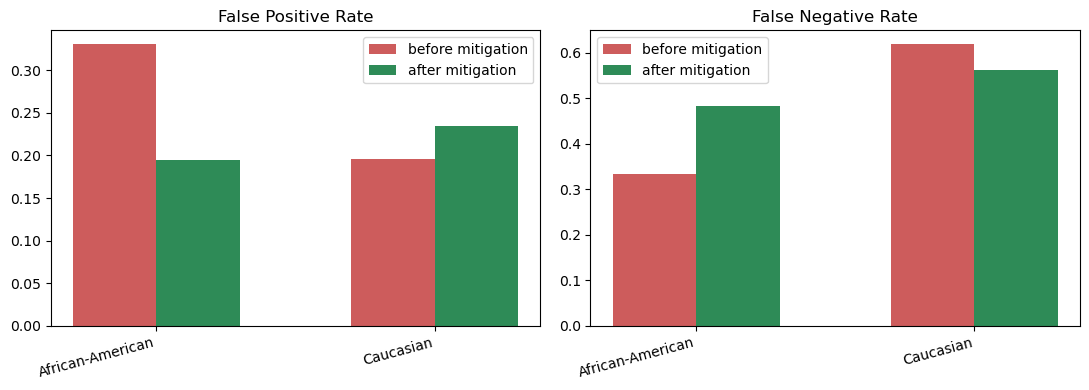

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11,4))
for ax, metric, title in zip(axes, ["fpr","fnr"], ["False Positive Rate","False Negative Rate"]):
    b = result["before"].set_index("group")[metric]
    a = result["after"].set_index("group")[metric]
    x = range(len(b))
    ax.bar([i-0.15 for i in x], b.values, width=0.3, label="before mitigation", color="indianred")
    ax.bar([i+0.15 for i in x], a.values, width=0.3, label="after mitigation", color="seagreen")
    ax.set_xticks(list(x)); ax.set_xticklabels(b.index, rotation=15, ha="right")
    ax.set_title(title); ax.legend()
plt.tight_layout()
plt.savefig("../outputs/mitigation_before_after.png", dpi=120, bbox_inches="tight")
plt.show()

## Equalized odds gap: before vs. after

In [6]:
print("Before mitigation:", result["before_equalized_odds_gap"])
print("After mitigation: ", result["after_equalized_odds_gap"])

gap_before = result["before_equalized_odds_gap"]["equalized_odds_gap"]
gap_after = result["after_equalized_odds_gap"]["equalized_odds_gap"]
print(f"\nRelative reduction: {(1 - gap_after/gap_before):.1%}")

Before mitigation: {'fpr_gap': 0.1345006514732439, 'tpr_gap': 0.28379647622749055, 'equalized_odds_gap': 0.28379647622749055}
After mitigation:  {'fpr_gap': 0.0394141312547146, 'tpr_gap': 0.07837802824200024, 'equalized_odds_gap': 0.07837802824200024}

Relative reduction: 72.4%


## What this mitigation costs

Equalizing error rates is not free — it can require raising the effective
threshold for the group with the higher false-positive rate, which trades some
accuracy/predictive-parity for error-rate parity. This is the accuracy/fairness
trade-off referenced throughout the fairness-ML literature; a real deployment
decision requires choosing which fairness criterion matters most for the specific
use case (pretrial risk assessment has different stakes than, say, loan approval),
not just running a mitigation library and declaring the problem solved.

In [7]:
print("Overall accuracy before:", (result['before']['n'] * result['before']['accuracy']).sum() / result['before']['n'].sum())
print("Overall accuracy after: ", (result['after']['n'] * result['after']['accuracy']).sum() / result['after']['n'].sum())

Overall accuracy before: 0.6559343434343434
Overall accuracy after:  0.6470959595959596


## Summary

Fairlearn's post-processing threshold optimizer reduced the equalized-odds gap
substantially with a modest accuracy cost, by design equalizing error rates rather
than optimizing a single group's accuracy. This demonstrates a concrete, working
mitigation path for the error-rate disparity found in `02_bias_audit.ipynb` — while
making explicit that mitigation is a design choice among competing fairness
definitions, not a free fix.